In [15]:
%pip install pandas yfinance matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


We will be using yahoo finance instead of coingecko as coingecko's free api has rate limits and only a lookback window of 365 days. We will also be main targeting digital assets with the largest market caps to reduce the bid-ask spread, minimisng the slippage in our strategy. 

In [16]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Fetch Data
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD']
print(f"Downloading data for {assets}...")

# Fetch daily closing prices
data = yf.download(assets, start='2020-01-01', end='2026-08-01')['Close']
data = data.ffill().dropna() # Drop initial NaNs where newer coins lacked data

print(f"Data loaded: {data.index[0].date()} to {data.index[-1].date()} | Shape: {data.shape}")

[*********************100%***********************]  3 of 3 completed

Data loaded: 2020-04-10 to 2026-07-31 | Shape: (2304, 3)


When calculating price momentum of a digital asset, we take the percentage change over the designated lookback period.

Using that from step 1, we shift the weights of our portfolio with respect to the realised rolling volatility. Referring to this paper (https://macrosynergy.com/research/the-point-of-volatility-targeting), this should help us contain our losses during market drawdowns, by selling off our digital assets to hold cash/stable-coins. In turn, the overall volatility of our portfolio should be less than the a simple-buy-and-hold portfolio. 

Given that coinbase advanced has a makers fee of 0.04% and takers fee of 0.6%, we will assume the strategy has a execution cost of 0.06% (cost_bps=60, 60 basis points = 0.06%)

In [ ]:
def calc_strat_returns(prices, lookback, vol_lookback=30, target_vol=0.50, max_leverage=1.0, cost_bps=60):
    """
    Computes the daily returns of the Volatility-Targeted TSMOM strategy.
    """
    returns = prices.pct_change()
    
    # 1. Momentum Signal
    mom = prices.pct_change(lookback)
    signal = np.sign(mom).shift(1)  # Shifted to prevent look-ahead bias
    
    # 2. Volatility Targeting
    rolling_vol = returns.rolling(vol_lookback).std() * np.sqrt(365)
    weight_mag = target_vol / rolling_vol.replace(0, np.nan)
    weight_mag = weight_mag.clip(upper=max_leverage).shift(1) # Shifted 1 day to prevent look-ahead bias
    
    # 3. Final Positions
    weights = signal * weight_mag
    weights = weights.fillna(0)
    
    # 4. Returns & Transaction Costs
    n_assets = len(prices.columns)
    strat_returns = (weights * returns).sum(axis=1) / n_assets
    
    # Turnover calculation (absolute daily change in weights)
    turnover = weights.diff().abs().sum(axis=1) / n_assets
    tc = turnover * (cost_bps / 10000) #calculates the cost of execution of trades
    
    net_returns = strat_returns - tc
    return net_returns

By using our Rolling Walk-forward engine, with every step of 90 days, we optimise our lookback parameters that will be used in our strategy for OOS trading days, this is done with a for loop of testing each parameter and ranking it by their sharpe ratios. 

In [18]:
# Strategy parameters space
lookbacks = [15, 30, 45, 60, 90, 120]
train_window = 365   # 1 year training
step = 90            # 3 months OOS step

# Pre-calculate strategy returns for all parameters over the full dataframe 
# (This strictly prevents NaN gap issues during train/test slicing while maintaining OOS integrity)
rets_dict = {lb: calc_strat_returns(data, lookback=lb) for lb in lookbacks}

oos_returns = pd.Series(dtype=float)
parameter_history = {}

# Warm-up period: 365 (Train) + 150 (Max lookback padding) = Start at index 515
start_idx = 515 

print("Starting Rolling Walk-Forward Optimization...")
for i in range(start_idx, len(data), step):
    train_start = i - train_window
    train_end = i
    test_start = i
    test_end = min(i + step, len(data))
    
    best_lb = None
    best_sharpe = -999
    
    # 1. Optimize In-Sample
    for lb in lookbacks:
        train_rets = rets_dict[lb].iloc[train_start:train_end]
        if train_rets.std() > 0:
            sharpe = train_rets.mean() / train_rets.std() * np.sqrt(365)
        else:
            sharpe = 0
            
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_lb = lb
            
    # 2. Record out-of-sample performance
    parameter_history[data.index[test_start]] = best_lb
    oos_returns = pd.concat([oos_returns, rets_dict[best_lb].iloc[test_start:test_end]])

# Create Benchmark: Equal-weighted Buy & Hold basket
bnh_returns = data.pct_change().mean(axis=1).iloc[start_idx:]
bnh_returns = bnh_returns.loc[oos_returns.index] # Align dates

Starting Rolling Walk-Forward Optimization...


We will then calculate all the necessary details on the performance of our strategy via the function below, with important details such as overall Sharpe ratio, Max drawdowns, Cummulative annual growth rate, and volatility. 

--- OUT OF SAMPLE PERFORMANCE ---
                       CAGR    Vol  Sharpe  Max DD
WFO TSMOM Strategy    0.151  0.417   0.544  -0.593
Buy & Hold Benchmark -0.037  0.664   0.276  -0.855


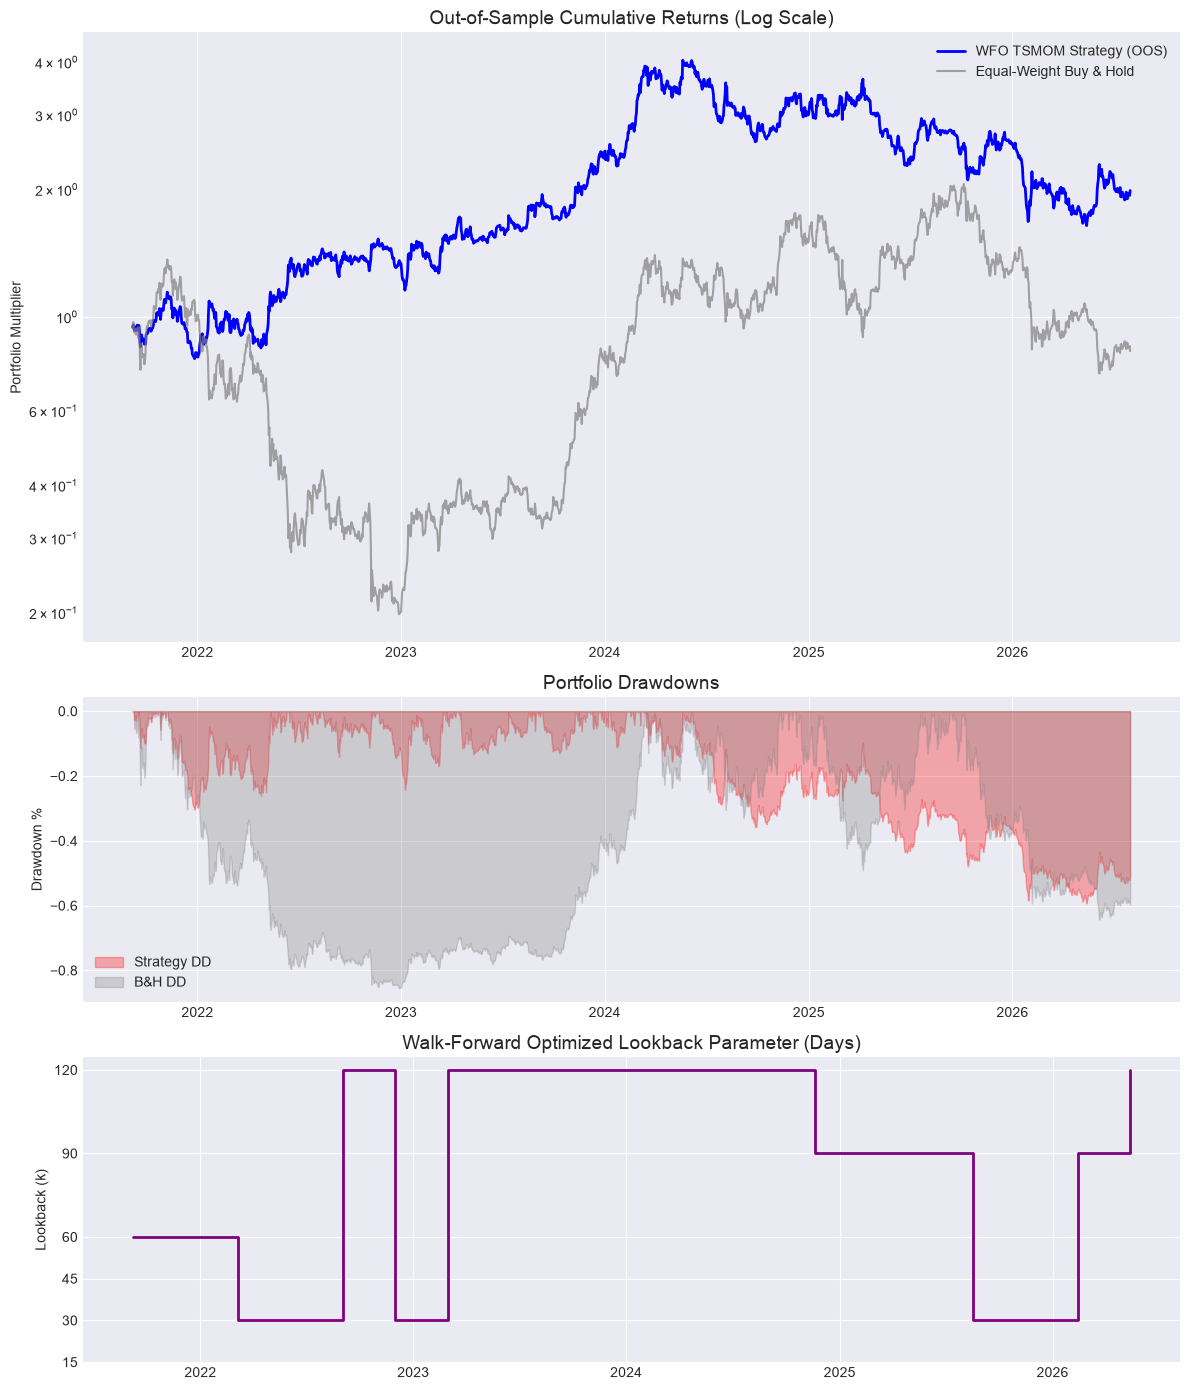

In [19]:
def calc_metrics(returns):
    cum_ret = (1 + returns).cumprod()
    cagr = (cum_ret.iloc[-1]) ** (365 / len(returns)) - 1
    vol = returns.std() * np.sqrt(365)
    sharpe = returns.mean() / returns.std() * np.sqrt(365)
    
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "Max DD": max_dd}

strat_metrics = calc_metrics(oos_returns)
bnh_metrics = calc_metrics(bnh_returns)

# Print Summary
print("--- OUT OF SAMPLE PERFORMANCE ---")
metrics_df = pd.DataFrame([strat_metrics, bnh_metrics], index=['WFO TSMOM Strategy', 'Buy & Hold Benchmark'])
print(metrics_df.round(3))

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), gridspec_kw={'height_ratios': [2, 1, 1]})

# Equity Curve
ax1.plot((1 + oos_returns).cumprod(), label='WFO TSMOM Strategy (OOS)', color='blue', linewidth=2)
ax1.plot((1 + bnh_returns).cumprod(), label='Equal-Weight Buy & Hold', color='gray', alpha=0.7)
ax1.set_title('Out-of-Sample Cumulative Returns (Log Scale)', fontsize=14)
ax1.set_yscale('log')
ax1.legend()
ax1.set_ylabel('Portfolio Multiplier')

# Drawdowns
def get_drawdown(rets):
    cum = (1 + rets).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

ax2.fill_between(oos_returns.index, get_drawdown(oos_returns), 0, color='red', alpha=0.3, label='Strategy DD')
ax2.fill_between(bnh_returns.index, get_drawdown(bnh_returns), 0, color='gray', alpha=0.3, label='B&H DD')
ax2.set_title('Portfolio Drawdowns', fontsize=14)
ax2.legend()
ax2.set_ylabel('Drawdown %')

# Parameter Evolution
params_s = pd.Series(parameter_history)
ax3.step(params_s.index, params_s.values, where='post', color='purple', linewidth=2)
ax3.set_title('Walk-Forward Optimized Lookback Parameter (Days)', fontsize=14)
ax3.set_ylabel('Lookback (k)')
ax3.set_yticks(lookbacks)

plt.tight_layout()
plt.show()

Some limitations in this strategy is the fact that is long-only that we did not include perpetuals so there is no mechanism for upside potential during bear markets as well as no possibilities to include more than 100% leverage during calmer markets. Based on the paper in cell 4, including leveraged positions during "calmer" markets can help with returns, "This opportunity for volatility targeting to ‘quietly’ outperform during calm periods is often overlooked." Furthermore, since the strategy employs volatility-targeted sizing, not including leverage would cap our potential upside during less volatile markets. 

Further improvements to the strategy, we could consider adding leveraging mechanisms such that we can profit more during calm markets, as well as the ability to hedge our long positions. 